# Lab 1
## Dynamic model of a multi-link manipulator

## Steps

### 0. Import the necessary libraries

In [203]:
from math import pi
import numpy as np
import roboticstoolbox as rtb
import matplotlib.pyplot as plt

### 1. Import robot model (KUKA IRB140)

In [204]:
robot = rtb.models.DH.IRB140()
print(robot)

DHRobot: IRB 140 (by ABB), 6 joints (RRRRRR), dynamics, geometry, standard DH parameters
┌─────┬───────┬──────┬────────┬─────────┬────────┐
│ θⱼ  │  dⱼ   │  aⱼ  │   ⍺ⱼ   │   q⁻    │   q⁺   │
├─────┼───────┼──────┼────────┼─────────┼────────┤
│  q1 │ 0.352 │ 0.07 │ -90.0° │ -180.0° │ 180.0° │
│  q2 │     0 │ 0.36 │   0.0° │ -100.0° │ 100.0° │
│  q3 │     0 │    0 │ -90.0° │ -220.0° │  60.0° │
│  q4 │  0.38 │    0 │  90.0° │ -200.0° │ 200.0° │
│  q5 │     0 │    0 │ -90.0° │ -120.0° │ 120.0° │
│  q6 │ 0.065 │    0 │   0.0° │ -400.0° │ 400.0° │
└─────┴───────┴──────┴────────┴─────────┴────────┘

┌──┬──┐
└──┴──┘

┌──────┬─────┬──────┬───────┬─────┬──────┬──────┐
│ name │ q0  │ q1   │ q2    │ q3  │ q4   │ q5   │
├──────┼─────┼──────┼───────┼─────┼──────┼──────┤
│   qr │  0° │ -90° │  90°  │  0° │  90° │ -90° │
│   qz │  0° │  0°  │  0°   │  0° │  0°  │  0°  │
│   qd │  0° │ -90° │  180° │  0° │  0°  │ -90° │
└──────┴─────┴──────┴───────┴─────┴──────┴──────┘



### 2. Fill in the parameters of the robot model (IRB140 specifications)

0. Using dyn() you can view the dynamic parameters of each link

In [220]:
print(robot.links[0].dyn())  # initial dynamic parameters of the first link

m     =        28 
r     =         0        0    0.085 
        |      0.2        0        0 | 
I     = |        0     0.28        0 | 
        |        0        0     0.24 | 
Jm    =   0.00045 
B     =    0.0018 
Tc    =      0.48(+)    -0.52(-) 
G     =       -74 
qlim  =        -3 to        3


1. Let's define the mass of the links

In [206]:
robot.links[0].m = 28.0
robot.links[1].m = 24.0
robot.links[2].m = 9.2
robot.links[3].m = 1.68
robot.links[4].m = 0.56
robot.links[5].m = 0.18

2. Let's define the center of mass of each link

In [207]:
robot.links[0].r = [0, 0, 0.085]
robot.links[1].r = [-0.32, 0, 0.18]
robot.links[2].r = [-0.25, 0, 0.10]
robot.links[3].r = [0, 0.015, 0]
robot.links[4].r = [0, 0, 0]
robot.links[5].r = [0, 0, 0.035]

3. Let's define the inertia tensor of each link. Filling: [Lxx, Lyy, Lzz, Lxy, Lyz, Lxz]

In [208]:
robot.links[0].I = [0.20, 0.28, 0.24, 0, 0, 0]
robot.links[1].I = [0.18, 0.35, 0.33, 0, 0, 0]
robot.links[2].I = [0.052, 0.082, 0.070, 0, 0, 0]
robot.links[3].I = [0.0020, 0.0016, 0.0020, 0, 0, 0]
robot.links[4].I = [0.00035, 0.00045, 0.00035, 0, 0, 0]
robot.links[5].I = [0.00010, 0.00010, 0.000040, 0, 0, 0]

4. Let's set the moment of inertia of the drive

In [209]:
robot.links[0].Jm = 0.00045
robot.links[1].Jm = 0.00045
robot.links[2].Jm = 0.00045
robot.links[3].Jm = 0.000040
robot.links[4].Jm = 0.000040
robot.links[5].Jm = 0.000040

5. Let's define the coefficient of viscous friction of the drive

In [210]:
robot.links[0].B = 0.0018
robot.links[1].B = 0.00100
robot.links[2].B = 0.00165
robot.links[3].B = 0.000085
robot.links[4].B = 0.000100
robot.links[5].B = 0.000044

6. Let's define the coefficient of Coulomb friction of the drive

In [211]:
robot.links[0].Tc = [0.48, -0.52]
robot.links[1].Tc = [0.155, -0.087]
robot.links[2].Tc = [0.160, -0.130]
robot.links[3].Tc = [0.0136, -0.0206]
robot.links[4].Tc = [0.0113, -0.0177]
robot.links[5].Tc = [0.00483, -0.0128]

7. Let's set the gear ratio for each link

In [212]:
robot.links[0].G = -73.5
robot.links[1].G = 127.0
robot.links[2].G = -63.0
robot.links[3].G = 89.5
robot.links[4].G = 84.5
robot.links[5].G = 90.0

8. Let's set restrictions on the generalized coordinates for each link

In [213]:
robot.links[0].qlim = [-2.96, 2.96]
robot.links[1].qlim = [-1.22, 2.44]
robot.links[2].qlim = [-3.73, 0.68]
robot.links[3].qlim = [-1.75, 2.95]
robot.links[4].qlim = [-1.58, 1.58]
robot.links[5].qlim = [-4.71, 4.71]

### 3. Set the initial and final positions of the robot and plot them

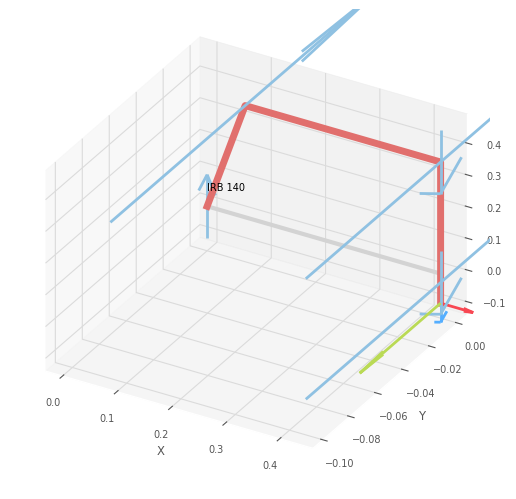

<Figure size 640x480 with 0 Axes>

In [214]:
q_start = [0, 0, 0, 0, 0, 0]
robot.plot(q_start)
plt.show()

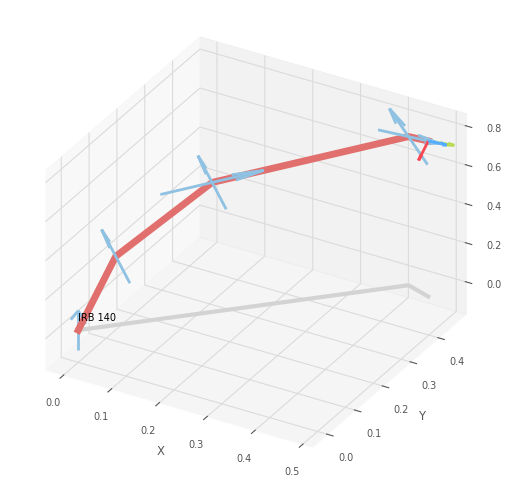

<Figure size 640x480 with 0 Axes>

In [215]:
q_end = [pi/4, -pi/3, -pi/4, pi/3, -pi/3, pi/4]
robot.plot(q_end)
plt.show()

### 4. Plan the trajectory with prebuilt functions

In [216]:
N = 100
t_start = 0
t_stop = 5
t_shag = t_stop/N
time = np.arange(t_start, t_stop, t_shag)
tr = rtb.jtraj(q_start, q_end, time)

### 5. Solve the inverse dynamics

In [217]:
# Scenario 1: Full dynamics with velocities and accelerations
tau = robot.rne(tr.q, tr.qd, tr.qdd).T

# Scenario 2: Quasi-static - velocities present but negligible accelerations
tau_quasi = robot.rne(tr.q, tr.qd, np.zeros([N,6])).T

# Scenario 3: Static holding - zero velocities and accelerations
tau0 = robot.rne(tr.q, np.zeros([N,6]), np.zeros([N,6])).T

### 6. Obtain the components of the dynamic equation

In [218]:
# Inertia matrix
M = robot.inertia(tr.q)

# Coriolis matrix for dynamic scenarios (Scenarios 1 & 2 use trajectory velocities)
C = robot.coriolis(tr.q, tr.qd)

# Coriolis matrix for static scenario (Scenario 3 - zero velocities)
C0 = robot.coriolis(tr.q, np.zeros([N,6]))

# Gravity vector
G = robot.gravload(tr.q)

### 7. Plot the graphs

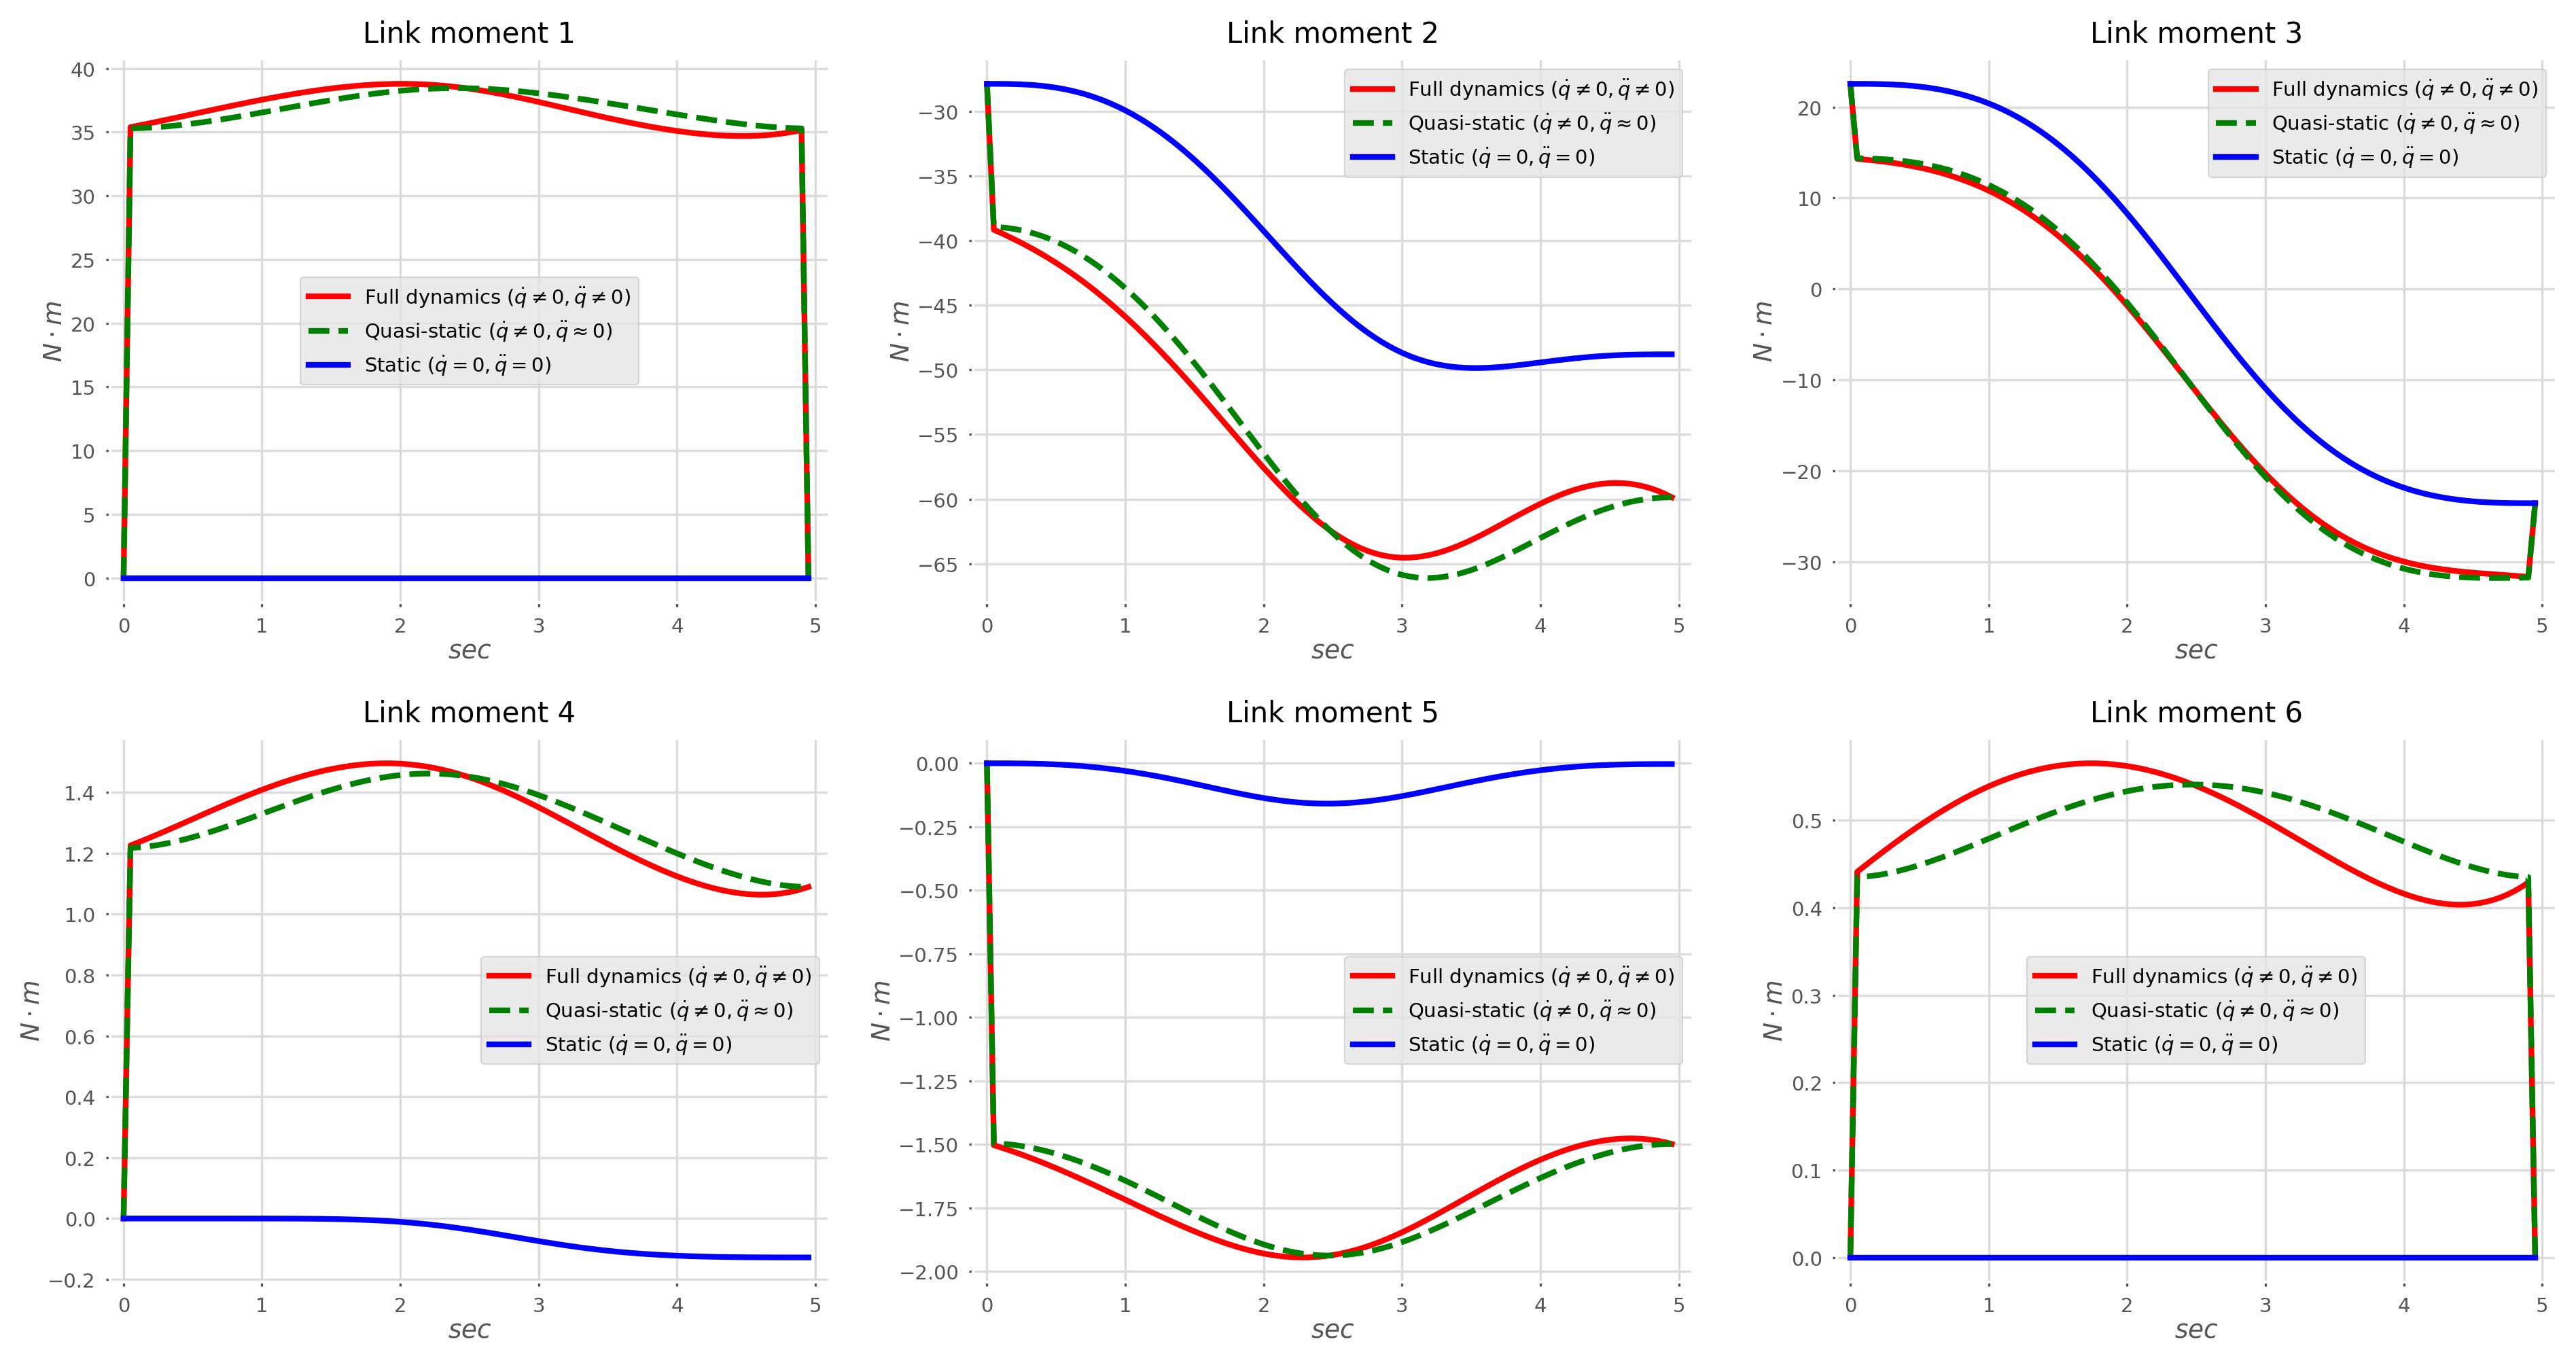

In [219]:
plt.figure(figsize=(12,6), dpi=300)
for g in range(6):
    plt.subplot(2,3,g+1)
    plt.subplots_adjust(left=0, bottom=0, right=1, top=1, wspace=0.2, hspace=0.25)
    plt.plot(time, tau[g], linewidth=2, label=r"Full dynamics ($\dot{q} \neq 0, \ddot{q} \neq 0$)", color='red')
    plt.plot(time, tau_quasi[g], linewidth=2, label=r"Quasi-static ($\dot{q} \neq 0, \ddot{q} \approx 0$)", color='green', linestyle='--')
    plt.plot(time, tau0[g], linewidth=2, label=r"Static ($\dot{q} = 0, \ddot{q} = 0$)", color='blue')
    plt.title(r"Link moment {}".format(g+1), fontsize=10)
    plt.ylabel(r"$N \cdot m$", fontsize=9)
    plt.xlabel(r"$sec$", fontsize=9)
    plt.grid(True)
    plt.legend(fontsize=7)
    ax = plt.gca()
    ax.set_facecolor((1,1,1))
    ax.set_xlim([t_start-0.1,t_stop+0.1])
plt.show()